## Предсказания TLM для VoiceBio

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

In [ ]:
PREDICTIONS_CSV = "/home/ext-ivanova-mk@ad.speechpro.com/test_dir/tlm/feature_extraction/voicebio_titanet_embeddings/voicebio_titanet_metadata_with_predictions.csv"

In [ ]:
df_preds = pd.read_csv(PREDICTIONS_CSV)

print(f"Ззаписей: {len(df_preds)}")
df_preds.head()

Ззаписей: 789


,person_id,birth_year,record_year,age,gender,file_path,embedding_path,embedding_dim,age_pred
0,id00021,1987,2020,33,female,/mnt/storage/work_dir/databases/voice_biometri...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,33.000000
1,id00021,1987,2019,32,female,/mnt/storage/work_dir/databases/voice_biometri...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,29.000000
2,id00021,1987,2022,35,female,/mnt/storage/work_dir/databases/voice_biometri...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,31.475083
3,id00021,1987,2021,34,female,/mnt/storage/work_dir/databases/voice_biometri...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,31.455889
4,id00021,1987,2023,36,female,/mnt/storage/work_dir/databases/voice_biometri...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,33.000000


In [17]:
df_preds['error'] = df_preds['age_pred'] - df_preds['age']
df_preds['abs_error'] = abs(df_preds['error'])
df_preds['squared_error'] = df_preds['error'] ** 2

MAE = df_preds['abs_error'].mean()
RMSE = np.sqrt(df_preds['squared_error'].mean())
STD_ERROR = df_preds['error'].std()

# Процент ошибок в пределах
within_1_year = (df_preds['abs_error'] <= 1).mean() * 100
within_3_years = (df_preds['abs_error'] <= 3).mean() * 100
within_5_years = (df_preds['abs_error'] <= 5).mean() * 100
within_10_years = (df_preds['abs_error'] <= 10).mean() * 100

print("\nМетрики оценки TLM модели на VouceBio")
print("\nОсновные метрики:")
print(f"MAE  (Mean Absolute Error):     {MAE:.3f} лет")
print(f"RMSE (Root Mean Squared Error): {RMSE:.3f} лет")
print(f"Std of Error (разброс ошибок):  {STD_ERROR:.3f} лет")

print("\nПроцент ошибок в пределах:")
print(f"  ≤ 1 год:   {within_1_year:.1f}%")
print(f"  ≤ 3 года:  {within_3_years:.1f}%")
print(f"  ≤ 5 лет:   {within_5_years:.1f}%")
print(f"  ≤ 10 лет:   {within_10_years:.1f}%")

print("\nСтатистика абсолютных ошибок:")
print(f"  Мин ошибка:  {df_preds['abs_error'].min():.3f} лет")
print(f"  Медиана:     {df_preds['abs_error'].median():.3f} лет")
print(f"  Макс ошибка: {df_preds['abs_error'].max():.3f} лет")


Метрики оценки TLM модели на VouceBio

Основные метрики:
MAE  (Mean Absolute Error):     5.683 лет
RMSE (Root Mean Squared Error): 8.358 лет
Std of Error (разброс ошибок):  7.952 лет

Процент ошибок в пределах:
  ≤ 1 год:   18.8%
  ≤ 3 года:  44.1%
  ≤ 5 лет:   64.0%
  ≤ 10 лет:   85.9%

Статистика абсолютных ошибок:
  Мин ошибка:  0.000 лет
  Медиана:     4.000 лет
  Макс ошибка: 37.619 лет


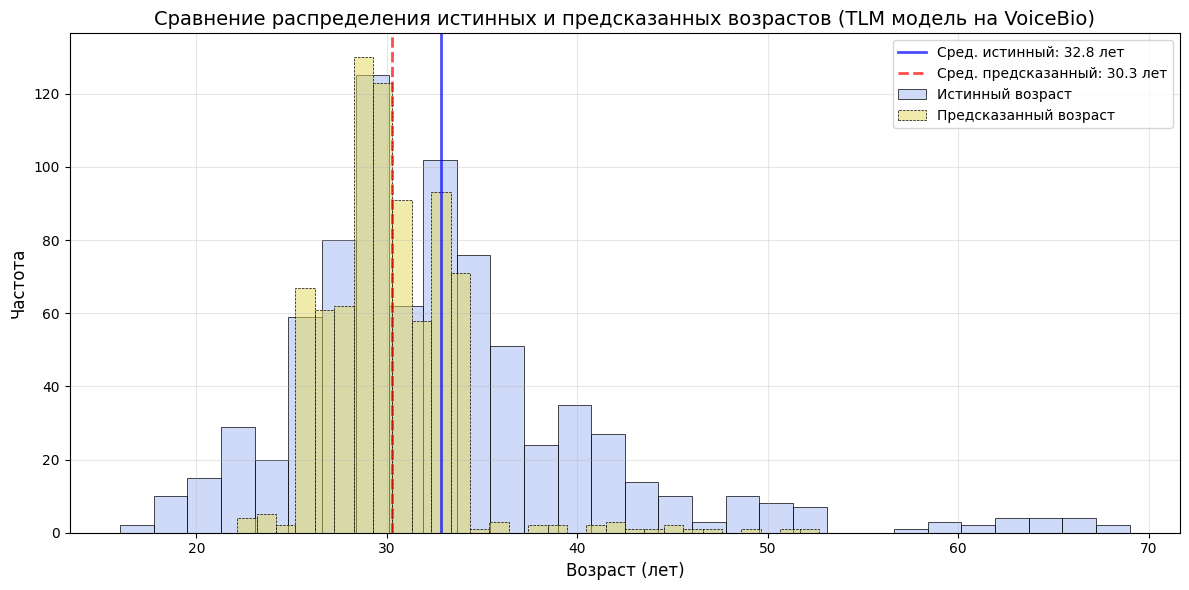

In [21]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_preds, x='age', bins=30, 
             color='#A1B7F4', alpha=0.5, label='Истинный возраст',
             edgecolor='black', linewidth=0.5)
sns.histplot(data=df_preds, x='age_pred', bins=30, 
             color="#E3D958", alpha=0.5, label='Предсказанный возраст',
             edgecolor='black', linewidth=0.5, linestyle='--')

plt.axvline(df_preds['age'].mean(), color='blue', linestyle='-', linewidth=2, alpha=0.7,
           label=f'Сред. истинный: {df_preds["age"].mean():.1f} лет')
plt.axvline(df_preds['age_pred'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Сред. предсказанный: {df_preds["age_pred"].mean():.1f} лет')

plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Сравнение распределения истинных и предсказанных возрастов (TLM модель на VoiceBio)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()